# S7C-D tentative initialization and causal recovery validation

This report compares the unchanged C1 baseline, the published D2 combined
variant, and the opt-in confirmation/recovery variant. The held-out unit is a
whole sequence; evaluation epochs within a sequence are dependent. Truth and
outlier labels are evaluator-only. The model remains strict constant velocity,
`Q=0`, exact retarded-time bearing physics, and positive-definite `R/P`.

In [1]:
from pathlib import Path
import csv

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
if not (ROOT / "results").exists():
    ROOT = ROOT.parent
RESULTS = ROOT / "results"

def read_csv(name):
    with (RESULTS / name).open(encoding="utf-8", newline="") as handle:
        return list(csv.DictReader(handle))

sequence = read_csv("initialization_recovery_sequence_results.csv")
summary = read_csv("initialization_recovery_summary.csv")
seeds = read_csv("initialization_recovery_seed_provenance.csv")
journal = read_csv("initialization_recovery_failure_journal.csv")

assert len(sequence) == 5400
assert len(summary) == 54
assert len(seeds) == 200
assert {row["base_seed"] for row in sequence} == {"20260914"}
assert not any(row["truth_used_by_estimator"].lower() == "true" for row in sequence)
print({"sequence_rows": len(sequence), "summary_rows": len(summary),
       "independent_base_blocks": len(seeds), "journal_rows": len(journal)})

{'sequence_rows': 5400, 'summary_rows': 54, 'independent_base_blocks': 200, 'journal_rows': 240}


## Held-out comparison

Conditional errors use valid final estimates only. Availability is therefore
shown beside them through final-valid and confirmed-epoch fractions. The
10 m and 50 m tail thresholds are diagnostic, not operational requirements.

In [2]:
columns = [
    "geometry", "profile", "variant", "final_valid_fraction",
    "conditional_position_rmse_m", "conditional_position_p95_m",
    "conditional_position_maximum_m",
    "conditional_position_error_gt_10m_fraction",
    "conditional_position_error_gt_50m_fraction",
    "conditional_state_95_coverage_fraction",
    "unconditional_valid_and_covered_fraction",
    "mean_confirmed_epoch_fraction", "mean_first_confirmation_time_s",
    "total_reset_count", "false_reset_count_evaluator_only",
]
focus = [
    {key: row[key] for key in columns}
    for row in summary
    if row["profile"] in {"nominal", "outlier_mild", "outlier_strong", "mixed"}
]
sorted(focus, key=lambda row: (row["geometry"], row["profile"], row["variant"]))

[{'geometry': 'informative',
  'profile': 'mixed',
  'variant': 'c1_baseline',
  'final_valid_fraction': '0.69',
  'conditional_position_rmse_m': '6.655623616185332',
  'conditional_position_p95_m': '11.58583209116005',
  'conditional_position_maximum_m': '21.743092029792408',
  'conditional_position_error_gt_10m_fraction': '0.14492753623188406',
  'conditional_position_error_gt_50m_fraction': '0.0',
  'conditional_state_95_coverage_fraction': '0.21739130434782608',
  'unconditional_valid_and_covered_fraction': '0.15',
  'mean_confirmed_epoch_fraction': '0.5107407407407407',
  'mean_first_confirmation_time_s': '3.2574826558753807',
  'total_reset_count': '0',
  'false_reset_count_evaluator_only': '0'},
 {'geometry': 'informative',
  'profile': 'mixed',
  'variant': 'confirmed_recovery',
  'final_valid_fraction': '1.0',
  'conditional_position_rmse_m': '0.8668105682864724',
  'conditional_position_p95_m': '1.701061466015711',
  'conditional_position_maximum_m': '2.254346813324965',
  'c

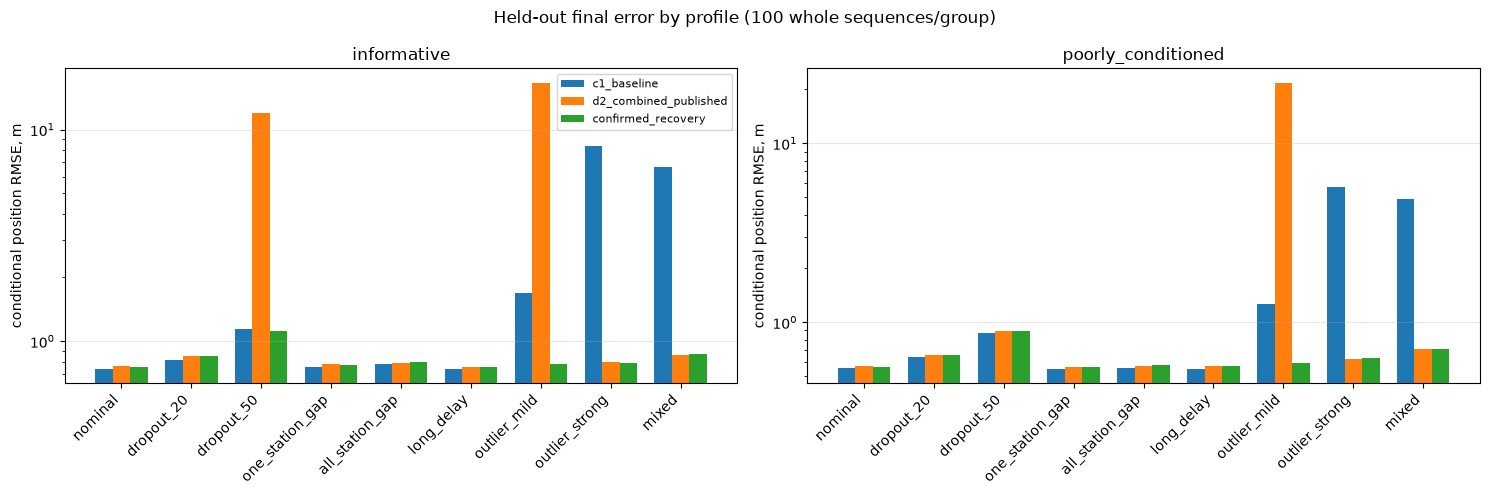

In [3]:
variant_order = ["c1_baseline", "d2_combined_published", "confirmed_recovery"]
profiles = list(dict.fromkeys(row["profile"] for row in summary))
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=False)
for axis, geometry in zip(axes, ["informative", "poorly_conditioned"]):
    selected = [row for row in summary if row["geometry"] == geometry]
    x = np.arange(len(profiles))
    width = 0.25
    for offset, variant in enumerate(variant_order):
        by_profile = {
            row["profile"]: float(row["conditional_position_rmse_m"])
            for row in selected if row["variant"] == variant
        }
        values = [by_profile[name] for name in profiles]
        axis.bar(x + (offset - 1) * width, values, width, label=variant)
    axis.set_title(geometry)
    axis.set_xticks(x, profiles, rotation=45, ha="right")
    axis.set_ylabel("conditional position RMSE, m")
    axis.set_yscale("log")
    axis.grid(axis="y", alpha=0.3)
axes[0].legend(fontsize=8)
fig.suptitle("Held-out final error by profile (100 whole sequences/group)")
fig.tight_layout()

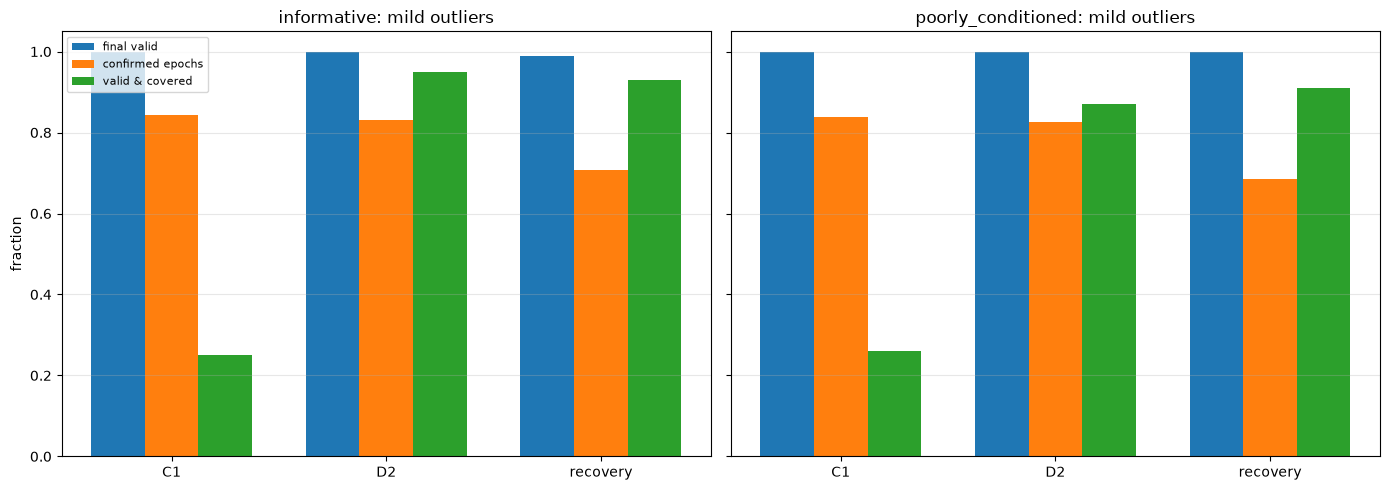

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for axis, geometry in zip(axes, ["informative", "poorly_conditioned"]):
    selected = {
        row["variant"]: row for row in summary
        if row["geometry"] == geometry and row["profile"] == "outlier_mild"
    }
    x = np.arange(len(variant_order))
    valid = [float(selected[name]["final_valid_fraction"]) for name in variant_order]
    confirmed = [float(selected[name]["mean_confirmed_epoch_fraction"]) for name in variant_order]
    covered = [float(selected[name]["unconditional_valid_and_covered_fraction"]) for name in variant_order]
    width = 0.25
    axis.bar(x - width, valid, width, label="final valid")
    axis.bar(x, confirmed, width, label="confirmed epochs")
    axis.bar(x + width, covered, width, label="valid & covered")
    axis.set_title(f"{geometry}: mild outliers")
    axis.set_xticks(x, ["C1", "D2", "recovery"])
    axis.set_ylim(0, 1.05)
    axis.grid(axis="y", alpha=0.3)
axes[0].set_ylabel("fraction")
axes[0].legend(fontsize=8)
fig.tight_layout()

## Reproduction of the two D2 initialization locks

The compact journal records only estimator-observable diagnostics online.
Position error and outlier labels are appended by the evaluator afterward.

In [5]:
failure_columns = [
    "case_id", "variant", "status", "valid", "evaluator_only_position_error_m"
]
failure_final = [
    {key: row[key] for key in failure_columns}
    for row in journal if row["record_kind"] == "final"
]
sorted(failure_final, key=lambda row: (row["case_id"], row["variant"]))

[{'case_id': 'informative:outlier_mild:57',
  'variant': 'c1_baseline',
  'status': 'confirmed',
  'valid': 'True',
  'evaluator_only_position_error_m': '1.3774061366529937'},
 {'case_id': 'informative:outlier_mild:57',
  'variant': 'confirmed_recovery',
  'status': 'confirmed',
  'valid': 'True',
  'evaluator_only_position_error_m': '0.11400692131891191'},
 {'case_id': 'informative:outlier_mild:57',
  'variant': 'd2_combined_published',
  'status': 'confirmed',
  'valid': 'True',
  'evaluator_only_position_error_m': '114.52006460072242'},
 {'case_id': 'poorly_conditioned:outlier_mild:37',
  'variant': 'c1_baseline',
  'status': 'confirmed',
  'valid': 'True',
  'evaluator_only_position_error_m': '2.4220943172435367'},
 {'case_id': 'poorly_conditioned:outlier_mild:37',
  'variant': 'confirmed_recovery',
  'status': 'confirmed',
  'valid': 'True',
  'evaluator_only_position_error_m': '0.7974262158417682'},
 {'case_id': 'poorly_conditioned:outlier_mild:37',
  'variant': 'd2_combined_publ

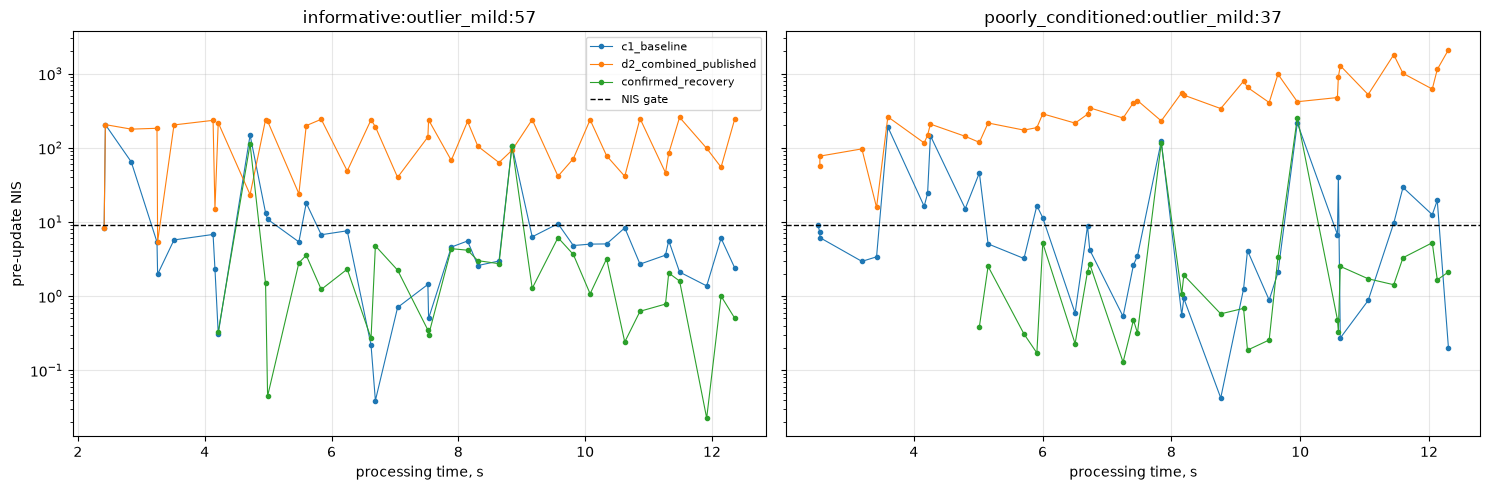

In [6]:
measurement_log = [row for row in journal if row["record_kind"] == "measurement"]
case_ids = sorted({row["case_id"] for row in measurement_log})
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for axis, case_id in zip(axes, case_ids):
    selected = [row for row in measurement_log if row["case_id"] == case_id]
    for variant in variant_order:
        rows = sorted(
            (row for row in selected if row["variant"] == variant),
            key=lambda row: float(row["processing_time_s"]),
        )
        axis.plot(
            [float(row["processing_time_s"]) for row in rows],
            [float(row["nis"]) for row in rows],
            marker=".", linewidth=0.8, label=variant,
        )
    axis.axhline(9.210340371976184, color="black", linestyle="--", linewidth=1, label="NIS gate")
    axis.set_yscale("log")
    axis.set_title(case_id)
    axis.set_xlabel("processing time, s")
    axis.grid(alpha=0.3)
axes[0].set_ylabel("pre-update NIS")
axes[0].legend(fontsize=8)
fig.tight_layout()

## Interpretation

- Independent confirmation removes the two reproduced D2 reject-locks and
  eliminates held-out final errors above 10 m for the confirmed recovery
  variant in this synthetic benchmark.
- This is not a free improvement: first confirmation is later and the mean
  confirmed-epoch fraction is lower. Two of 1,800 recovery profile-runs are
  final-invalid, including one censored recovery.
- Conditional covariance coverage is reported rather than assumed. The
  benchmark does not validate manoeuvres, `Q>0`, adaptive noise models, an
  acoustic frontend, or field robustness.